In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.utils.confusion import (
    build_entity_confusion_matrix,
    ids_to_bio,
    highlight_hierarchy_confusions,
)
from src.utils.label_mapping import get_crossner_labels

In [3]:
def load_preds(mode: str):
    files = sorted(Path("../results/metrics").glob(f"preds_{mode}_*.json"))
    if not files:
        raise FileNotFoundError(f"No preds file for mode={mode}")
    print(f"Loading {files[-1]}")
    with open(files[-1]) as f:
        return json.load(f)

label_list = get_crossner_labels()
id2label = {i: l for i, l in enumerate(label_list)}

no_dapt = load_preds("transfer")  # baseline
dapt    = load_preds("dapt")      # adapted

Loading ../results/metrics/preds_transfer_20260426_110251.json
Loading ../results/metrics/preds_dapt_20260426_110525.json


In [4]:
entity_types = sorted({
    l[2:] for l in label_list if l.startswith(("B-", "I-"))
})

no_dapt_preds = ids_to_bio(no_dapt["preds"], id2label)
no_dapt_refs  = ids_to_bio(no_dapt["refs"],  id2label)
dapt_preds    = ids_to_bio(dapt["preds"],    id2label)
dapt_refs     = ids_to_bio(dapt["refs"],     id2label)

mat_nodapt, labels_nodapt = build_entity_confusion_matrix(no_dapt_preds, no_dapt_refs, entity_types)
mat_dapt,   labels_dapt   = build_entity_confusion_matrix(dapt_preds,   dapt_refs,   entity_types)

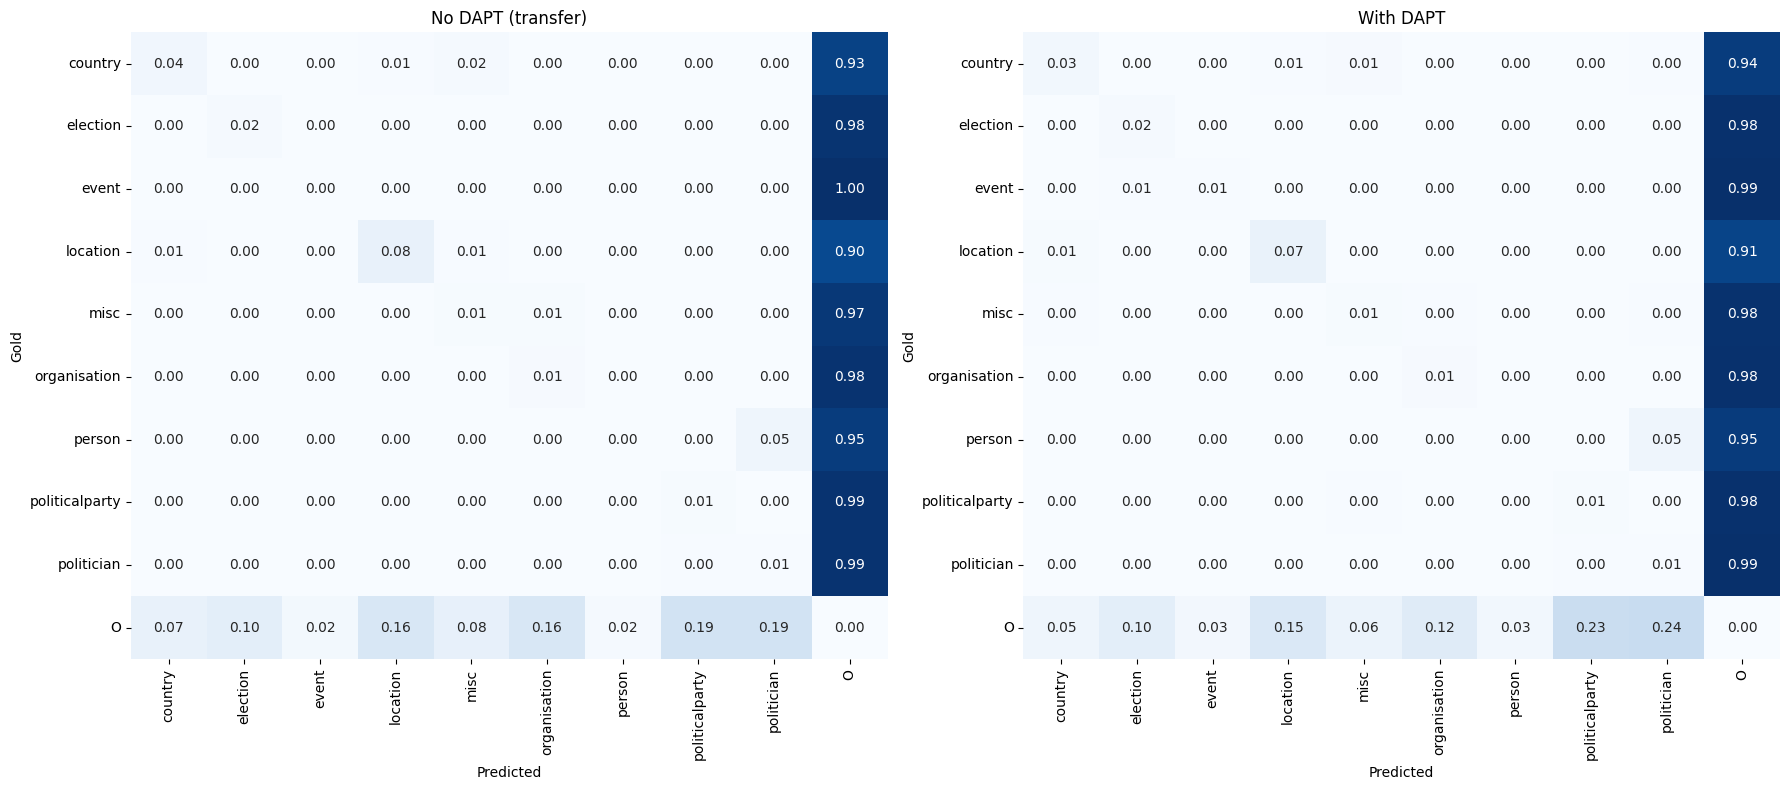

In [5]:
def plot_confusion(ax, matrix, labels, title, normalize=True):
    if normalize:
        row_sums = matrix.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        matrix_display = matrix / row_sums
        fmt = ".2f"
    else:
        matrix_display = matrix
        fmt = "d"

    sns.heatmap(matrix_display, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=labels, yticklabels=labels, cbar=False, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plot_confusion(axes[0], mat_nodapt, labels_nodapt, "No DAPT (transfer)")
plot_confusion(axes[1], mat_dapt,   labels_dapt,   "With DAPT")
plt.tight_layout()
plt.savefig("../results/metrics/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
hierarchy_pairs = [
    ("politician", "person"),
    ("country", "location"),
    ("politicalparty", "organisation"),
    ("person", "politician"),
    ("location", "country"),
    ("organisation", "politicalparty"),
]

hier_nodapt = highlight_hierarchy_confusions(mat_nodapt, labels_nodapt, hierarchy_pairs)
hier_dapt   = highlight_hierarchy_confusions(mat_dapt,   labels_dapt,   hierarchy_pairs)

print(f"{'Pair':<35} {'No DAPT':<10} {'With DAPT':<10} Change")
print("-" * 70)
for pair in hier_nodapt:
    a, b = hier_nodapt[pair], hier_dapt[pair]
    change = b - a
    arrow = "↓" if change < 0 else ("↑" if change > 0 else "=")
    print(f"{pair:<35} {a:<10} {b:<10} {arrow} {abs(change)}")

Pair                                No DAPT    With DAPT  Change
----------------------------------------------------------------------
politician -> person                0          0          = 0
country -> location                 3          3          = 0
politicalparty -> organisation      1          0          ↓ 1
person -> politician                17         17         = 0
location -> country                 4          5          ↑ 1
organisation -> politicalparty      0          0          = 0
